# Desktop parameter search — round 2 (re-anchored to current data)

Re-anchored to the latest data: **forecast_start 2026-07-06** (training_end 2026-07-05, the freshest
complete day). Fresh data alone moved the center to **48,520,449** final (from 48,481,092 at the stale
2026-06-29 anchor). **Target 48,584,362 → gap +63,913**; up to +10k available from headwind softening.

Focus (per Brendan): the **top-3 levers only** — `holiday_threshold`, `changepoint_prior_scale`,
`changepoint_range` (holiday min/max radius dropped). Larger δ single-knob scans + **combinations** of
their KPI-raising directions (threshold up, cps down, cpr down).

- Runner: `scripts/run_param_scan.py`; driver: `scripts/run_desktop_gradient.py --round 2`.
- `l`+`o` overlays applied (specs re-anchored to 2026-07-06); Win10 headwind (−1,370,000) added at
  the display layer here, not in the scan.
- Outputs: `results.csv` + `plots/desktop_gradient_round2/{threshold,cps,cpr}_scan.png` + `combos.png`.


In [1]:
# [gr2-setup]
import os
import glob
import json
import sys
import time
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"],
                        capture_output=True, text=True).stdout.strip())

# --- Paths ---
ROUND_DIR = "research/param-scans/results/desktop_gradient_round2"
PLOTS_DIR = "research/param-scans/plots/desktop_gradient_round2"
ADJUSTMENTS_DIR = "data-official/2026-07/adjustments"
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- Dates: RE-ANCHORED to current data (forecast_start 2026-07-06, training_end 2026-07-05) ---
FORECAST_START = pd.Timestamp("2026-07-06")
FORECAST_START_STR = "2026-07-06"
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")
BQ_START = "2025-12-04"

# --- Reference numbers (re-anchored center, verified) ---
HEADWIND_DEC15 = -1_370_000
CENTER_KPI_PRE = 49_890_449      # re-anchored center, pre-headwind Dec-15 28d-MA
CURRENT_FINAL = 48_520_449       # = CENTER_KPI_PRE + HEADWIND_DEC15
TARGET_FINAL = 48_584_362        # param-search target (final KPI); gap = +63,913

# --- Package defaults (for classifying which knobs a probe changed) ---
DEFAULTS = {
    "prophet_changepoint_prior_scale": 0.15983, "prophet_recent_weeks": 13,
    "prophet_changepoint_range": 0.7, "prophet_n_changepoints": 25,
    "holiday_threshold": -0.032, "holiday_max_radius": 5,
    "holiday_min_radius": 3, "holiday_effect_floor": -0.6,
}
SHORT = {"prophet_changepoint_prior_scale": "cps", "prophet_changepoint_range": "cpr",
         "holiday_threshold": "threshold"}

print(f"Re-anchored center final = {CURRENT_FINAL:,}   target = {TARGET_FINAL:,}   "
      f"gap = {TARGET_FINAL - CURRENT_FINAL:+,}")


Re-anchored center final = 48,520,449   target = 48,584,362   gap = +63,913


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [gr2-helpers]
sys.path.insert(0, "data-official/2026-06")
from export_canonical_curves import display_ma  # noqa: E402

SEG_ALL = '{"os": "ALL"}'


def daily_to_28ma(dates, values):
    s = pd.Series(np.asarray(values, dtype=float), index=pd.to_datetime(np.asarray(dates)))
    return s.sort_index().rolling(28).mean()


def render_adjustment(spec, date_index):
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx)
    if spec["type"] == "linear_ramp":
        start = pd.Timestamp(spec["start_date"])
        anchor = pd.Timestamp(spec["anchor_date"])
        total_days = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get("desktop_dau", 0) * elapsed / total_days
    elif spec["type"] == "step":
        start = pd.Timestamp(spec["start_date"])
        end = pd.Timestamp(spec["end_date"]) if "end_date" in spec else idx[-1]
        desktop[(idx >= start) & (idx <= end)] = spec.get("desktop_dau", 0)
    return desktop


def load_desktop_adjustment(date_index):
    idx = pd.DatetimeIndex(date_index)
    total = pd.Series(0.0, index=idx)
    for path in sorted(glob.glob(f"{ADJUSTMENTS_DIR}/*.json")):
        with open(path) as f:
            total += render_adjustment(json.load(f), idx)
    return total


def find_probe_parquet(label):
    hits = glob.glob(
        f"{ROUND_DIR}/{label}/*/mozaic_daily_forecast.{FORECAST_START_STR}.ld-D.adj-lo.parquet")
    return hits[0] if hits else None


def probe_config(label):
    pj = glob.glob(f"{ROUND_DIR}/{label}/*/parameters.json")
    return json.load(open(pj[0]))["config"] if pj else None


def nondefault(cfg):
    return {k: v for k, v in cfg.items() if abs(v - DEFAULTS[k]) > 1e-9}


def all_desktop_daily(parquet_path):
    df = pd.read_parquet(parquet_path)
    df["target_date"] = pd.to_datetime(df["target_date"])
    m = df[(df.data_source == "legacy_desktop") & (df.country == "ALL")
           & (df.app_name == "desktop") & (df.segment == SEG_ALL)]
    return m.sort_values("target_date")[["target_date", "dau"]].reset_index(drop=True)


def dec15_pre_headwind(parquet_path):
    d = all_desktop_daily(parquet_path)
    s = d.set_index("target_date")["dau"].astype(float)
    return float(s.rolling(28, min_periods=28).mean().loc[MEASUREMENT_DATE])


def forecast_ma_final(parquet_path):
    d = all_desktop_daily(parquet_path)
    ma = display_ma(d["target_date"], d["dau"], FORECAST_START)
    adj = load_desktop_adjustment(ma.index)
    out = ma.copy()
    fmask = out.index >= FORECAST_START
    out[fmask] = out[fmask] + adj[fmask]
    return out


In [3]:
# [gr2-actuals]
client = bigquery.Client(project="moz-fx-data-bq-data-science")
sql = f"""
    SELECT submission_date AS date, SUM(dau) AS dau
    FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
    WHERE app_name = "Firefox Desktop"
      AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
    GROUP BY submission_date ORDER BY 1
"""
t0 = time.time()
sys.stdout.write("querying desktop actuals...")
sys.stdout.flush()
desktop_actuals = client.query(sql).to_dataframe()
desktop_actuals["date"] = pd.to_datetime(desktop_actuals["date"])
desktop_actual_ma = daily_to_28ma(desktop_actuals["date"], desktop_actuals["dau"])
sys.stdout.write(f" {len(desktop_actuals)} rows ({time.time() - t0:.1f}s); "
                 f"latest {desktop_actuals['date'].max().date()}\n")


querying desktop actuals...

 214 rows (7.5s); latest 2026-07-05


36

In [4]:
# [gr2-results-table]
labels = sorted(d for d in os.listdir(ROUND_DIR) if os.path.isdir(f"{ROUND_DIR}/{d}"))
center_pre = dec15_pre_headwind(find_probe_parquet("center"))
assert abs(center_pre - CENTER_KPI_PRE) < 1, f"center drift: {center_pre:,.0f} vs {CENTER_KPI_PRE:,}"

rows = []
for lab in labels:
    pq = find_probe_parquet(lab)
    if pq is None:
        print(f"WARNING: no parquet for {lab}")
        continue
    nd = nondefault(probe_config(lab))
    pre = dec15_pre_headwind(pq)
    rows.append({
        "label": lab,
        "changes": ", ".join(f"{SHORT.get(k, k)}={v:g}" for k, v in nd.items()) or "center",
        "n_knobs": len(nd),
        "pre": pre,
        "final": pre + HEADWIND_DEC15,
        "vs_center": pre - center_pre,
        "vs_target": (pre + HEADWIND_DEC15) - TARGET_FINAL,
    })
res = pd.DataFrame(rows).sort_values("final", ascending=False).reset_index(drop=True)
res.to_csv(f"{ROUND_DIR}/results.csv", index=False)

print(f"center final = {center_pre + HEADWIND_DEC15:,.0f}   target = {TARGET_FINAL:,}   "
      f"gap = {TARGET_FINAL - (center_pre + HEADWIND_DEC15):+,.0f}")
print("(vs_target > 0 means the config OVERSHOOTS the target, params-only, before any headwind spend)\n")
show = res.copy()
for c in ["final"]:
    show[c] = show[c].map(lambda v: f"{v:,.0f}")
for c in ["vs_center", "vs_target"]:
    show[c] = show[c].map(lambda v: f"{v:+,.0f}")
print(show[["label", "changes", "final", "vs_center", "vs_target"]].to_string(index=False))
res


center final = 48,520,449   target = 48,584,362   gap = +63,913
(vs_target > 0 means the config OVERSHOOTS the target, params-only, before any headwind spend)

                       label                                 changes      final vs_center vs_target
combo__thr017_cps08983_cpr55 cpr=0.55, threshold=-0.017, cps=0.08983 48,556,077   +35,627   -28,285
                   cpr__0.55                                cpr=0.55 48,533,021   +12,572   -51,341
                cps__0.08983                             cps=0.08983 48,532,551   +12,102   -51,811
                thresh__m017                        threshold=-0.017 48,530,456   +10,007   -53,906
                cps__0.10983                             cps=0.10983 48,526,315    +5,866   -58,047
       combo__cps10983_cpr60                    cpr=0.6, cps=0.10983 48,524,191    +3,742   -60,171
                   cpr__0.60                                 cpr=0.6 48,522,507    +2,058   -61,855
                      center            

,label,changes,n_knobs,pre,final,vs_center,vs_target
0,combo__thr017_cps08983_cpr55,"cpr=0.55, threshold=-0.017, cps=0.08983",3,4.992608e+07,4.855608e+07,35627.498729,-28285.497164
1,cpr__0.55,cpr=0.55,1,4.990302e+07,4.853302e+07,12571.627209,-51341.368683
2,cps__0.08983,cps=0.08983,1,4.990255e+07,4.853255e+07,12102.124616,-51810.871276
3,thresh__m017,threshold=-0.017,1,4.990046e+07,4.853046e+07,10007.284901,-53905.710991
4,cps__0.10983,cps=0.10983,1,4.989632e+07,4.852632e+07,5866.450084,-58046.545808
5,combo__cps10983_cpr60,"cpr=0.6, cps=0.10983",2,4.989419e+07,4.852419e+07,3741.906654,-60171.089238
6,cpr__0.60,cpr=0.6,1,4.989251e+07,4.852251e+07,2058.419644,-61854.576248
7,center,center,0,4.989045e+07,4.852045e+07,0.000000,-63912.995892
8,combo__thr022_cps10983,"threshold=-0.022, cps=0.10983",2,4.988264e+07,4.851264e+07,-7810.283466,-71723.279358
9,thresh__m022,threshold=-0.022,1,4.987376e+07,4.850376e+07,-16693.446146,-80606.442039


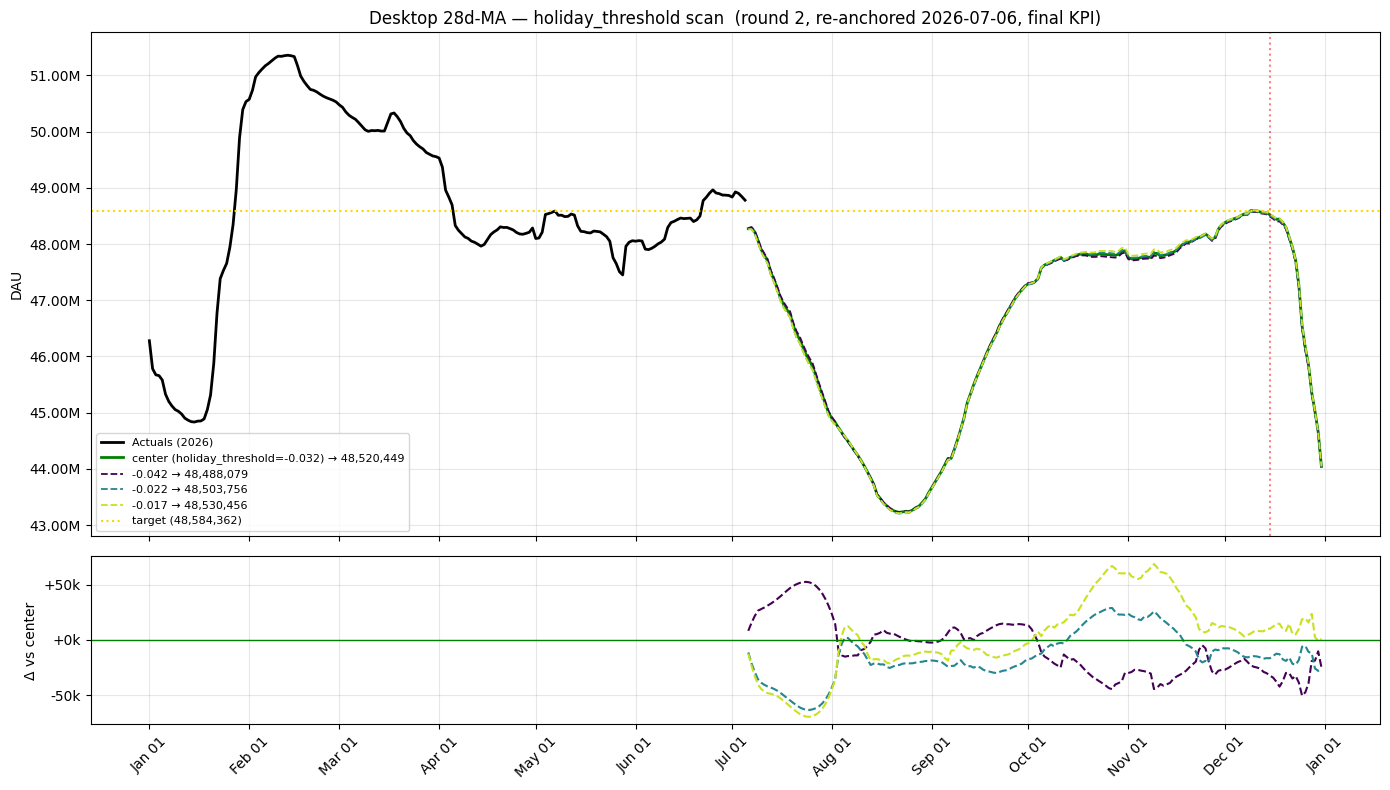

saved research/param-scans/plots/desktop_gradient_round2/threshold_scan.png


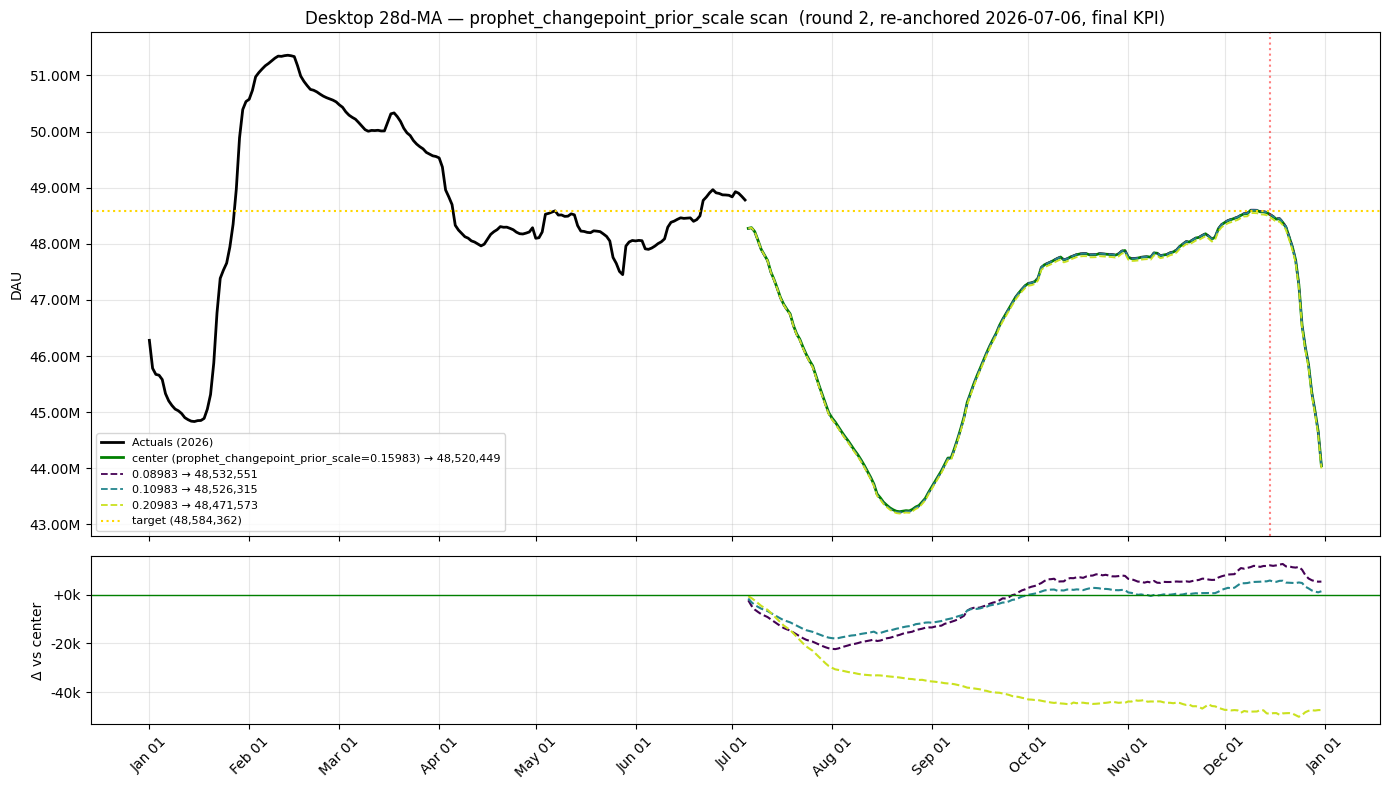

saved research/param-scans/plots/desktop_gradient_round2/cps_scan.png


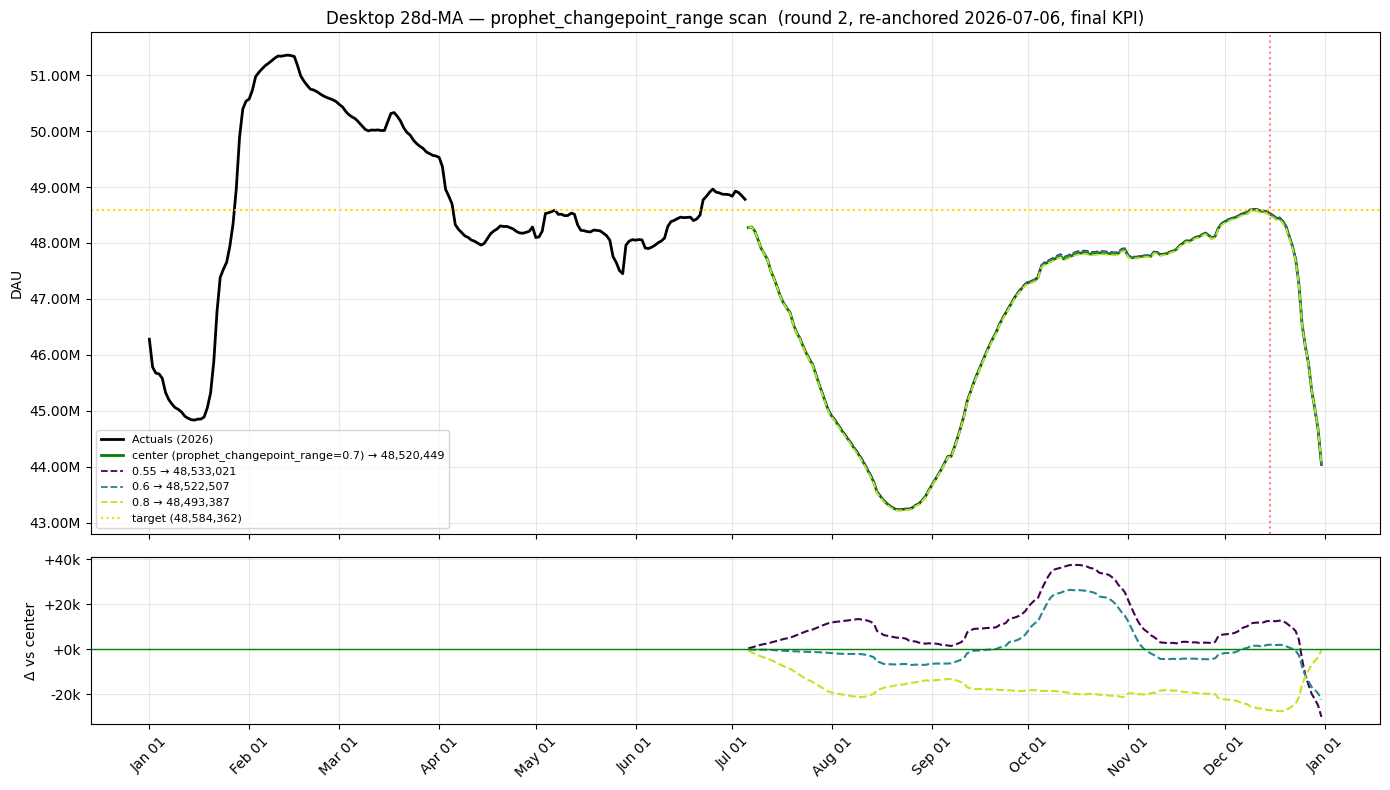

saved research/param-scans/plots/desktop_gradient_round2/cpr_scan.png


In [5]:
# [gr2-single-knob-scans]
def clip_display(s):
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()


def clip_fc(s):
    return s[(s.index >= FORECAST_START) & (s.index <= DISPLAY_END)].dropna()


def mfmt(x, pos):
    return f"{x / 1e6:.2f}M"


center_ma = forecast_ma_final(find_probe_parquet("center"))

for field, short in [("holiday_threshold", "threshold"),
                     ("prophet_changepoint_prior_scale", "cps"),
                     ("prophet_changepoint_range", "cpr")]:
    variants = []
    for lab in labels:
        if lab == "center":
            continue
        nd = nondefault(probe_config(lab))
        if len(nd) == 1 and field in nd:
            variants.append((nd[field], lab))
    variants.sort()
    if not variants:
        continue

    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1]})
    ax.plot(clip_display(desktop_actual_ma), color="black", lw=2, label="Actuals (2026)")
    ax.plot(clip_fc(center_ma), color="green", lw=2,
            label=f"center ({field}={DEFAULTS[field]:g}) → {center_ma.loc[MEASUREMENT_DATE]:,.0f}")
    colors = cm.viridis(np.linspace(0, 0.92, len(variants)))
    for (val, lab), col in zip(variants, colors):
        ma = forecast_ma_final(find_probe_parquet(lab))
        ax.plot(clip_fc(ma), color=col, lw=1.3, ls="--",
                label=f"{val:g} → {ma.loc[MEASUREMENT_DATE]:,.0f}")
        d = clip_fc(ma - center_ma)
        ax2.plot(d.index, d.values, color=col, ls="--")
    ax.axhline(TARGET_FINAL, color="gold", ls=":", lw=1.5, label=f"target ({TARGET_FINAL:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", ls=":", alpha=0.5)
    ax.set_title(f"Desktop 28d-MA — {field} scan  (round 2, re-anchored 2026-07-06, final KPI)",
                 fontsize=12)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(mfmt))
    ax.legend(loc="lower left", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax2.axhline(0, color="green", lw=1)
    ax2.set_ylabel("Δ vs center")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    plt.tight_layout()
    out = f"{PLOTS_DIR}/{short}_scan.png"
    plt.savefig(out, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"saved {out}")


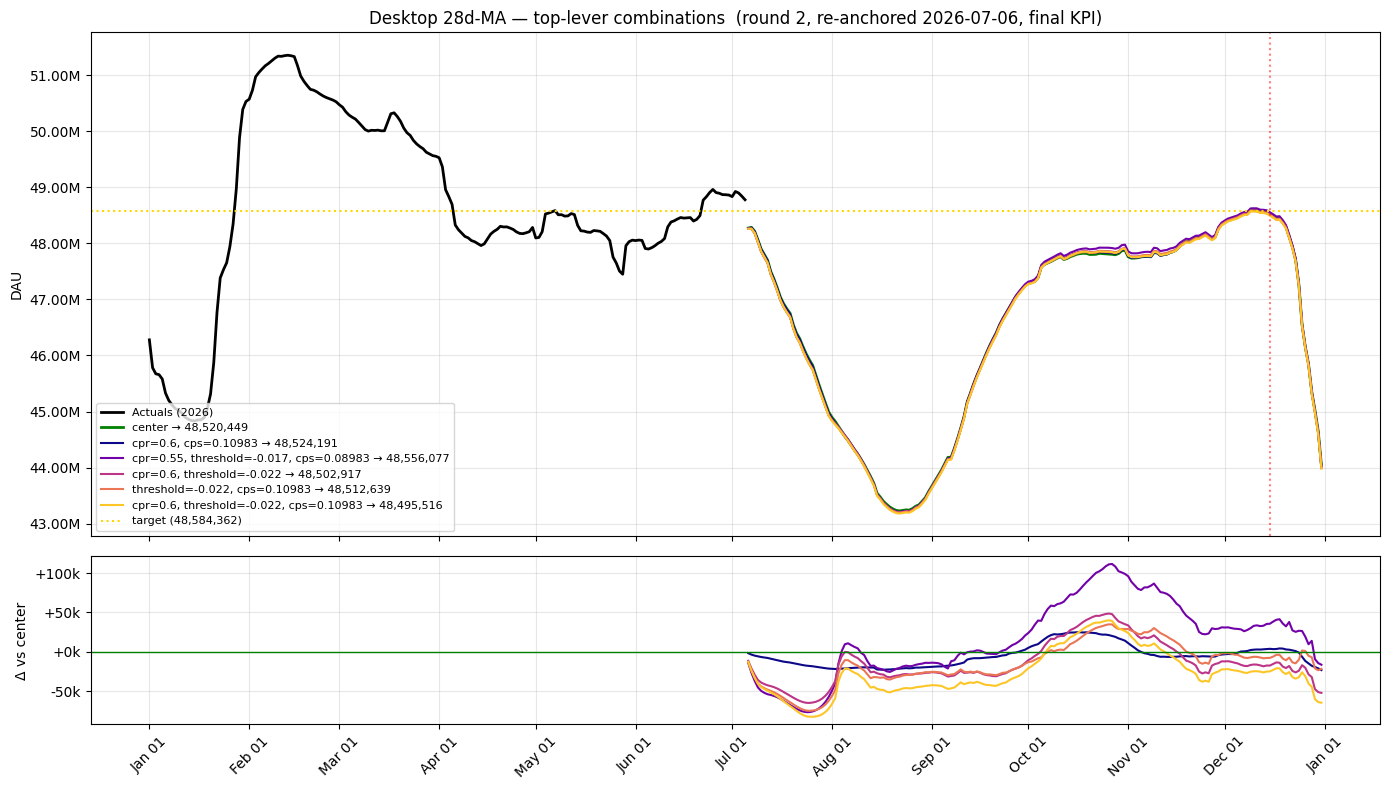

saved research/param-scans/plots/desktop_gradient_round2/combos.png


In [6]:
# [gr2-combo-plot]
combo_labels = [l for l in labels if l.startswith("combo__")]

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
ax.plot(clip_display(desktop_actual_ma), color="black", lw=2, label="Actuals (2026)")
ax.plot(clip_fc(center_ma), color="green", lw=2,
        label=f"center → {center_ma.loc[MEASUREMENT_DATE]:,.0f}")
colors = cm.plasma(np.linspace(0, 0.88, max(1, len(combo_labels))))
for lab, col in zip(combo_labels, colors):
    ma = forecast_ma_final(find_probe_parquet(lab))
    nd = nondefault(probe_config(lab))
    desc = ", ".join(f"{SHORT.get(k, k)}={v:g}" for k, v in nd.items())
    ax.plot(clip_fc(ma), color=col, lw=1.5, label=f"{desc} → {ma.loc[MEASUREMENT_DATE]:,.0f}")
    d = clip_fc(ma - center_ma)
    ax2.plot(d.index, d.values, color=col)
ax.axhline(TARGET_FINAL, color="gold", ls=":", lw=1.5, label=f"target ({TARGET_FINAL:,})")
ax.axvline(MEASUREMENT_DATE, color="red", ls=":", alpha=0.5)
ax.set_title("Desktop 28d-MA — top-lever combinations  (round 2, re-anchored 2026-07-06, final KPI)",
             fontsize=12)
ax.set_ylabel("DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(mfmt))
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)
ax2.axhline(0, color="green", lw=1)
ax2.set_ylabel("Δ vs center")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
out = f"{PLOTS_DIR}/combos.png"
plt.savefig(out, dpi=130, bbox_inches="tight")
plt.show()
print(f"saved {out}")
